1. Incarcarea si normalizarea datelor

In [6]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Dimensiune x_train:", x_train.shape)
print("Dimensiune x_test:", x_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Valoare minima:", x_train.min())
print("Valoare maxima:", x_train.max())

Dimensiune x_train: (60000, 28, 28)
Dimensiune x_test: (10000, 28, 28)
Valoare minima: 0.0
Valoare maxima: 1.0


2. Crearea modelului Sequential

In [3]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

3. Antrenarea modelului

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.9880 - loss: 0.0379
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - accuracy: 0.9911 - loss: 0.0289
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 513us/step - accuracy: 0.9927 - loss: 0.0230
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.9939 - loss: 0.0194
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - accuracy: 0.9951 - loss: 0.0161
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step - accuracy: 0.9777 - loss: 0.0816
Test loss: 0.08161718398332596
Test accuracy: 0.9776999950408936


4. Afisarea unei imagini

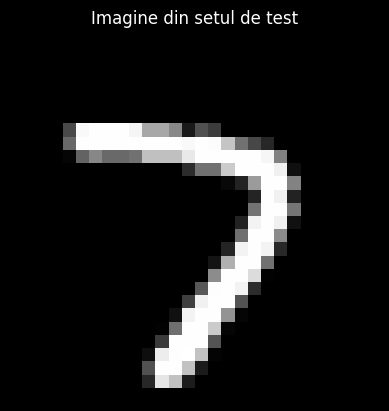

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step
Cifra prezisa: 7
Cifra reala: 7


In [10]:
index = 17

plt.imshow(x_test[index], cmap='gray')
plt.title("Imagine din setul de test")
plt.axis('off')
plt.show()

prediction = model.predict(x_test)

predicted_digit = np.argmax(prediction[index])

print("Cifra prezisa:", predicted_digit)
print("Cifra reala:", y_test[index])

5. Modificarea numarului de neuroni

In [12]:
# Model cu mai multi neuroni in stratul ascuns

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test accuracy:", test_accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9409 - loss: 0.2006
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9755 - loss: 0.0806
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9838 - loss: 0.0531
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9883 - loss: 0.0373
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9908 - loss: 0.0278
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - accuracy: 0.9791 - loss: 0.0756
Test accuracy: 0.9790999889373779


Observatie:
Dupa cresterea numarului de neuroni din stratul ascuns la 512, acuratetea modelului a crescut usor. Totusi, timpul de antrenare a fost mai mare, deoarece modelul a devenit mai complex.

6. Schimbarea numarului de epoci

In [13]:
# Antrenarea modelului cu mai multe epoci

model.fit(x_train, y_train, epochs=10)

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test accuracy:", test_accuracy)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9933 - loss: 0.0214
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9948 - loss: 0.0170
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9948 - loss: 0.0152
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9966 - loss: 0.0110
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9959 - loss: 0.0119
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9971 - loss: 0.0088
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9973 - loss: 0.0083
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9973 - loss: 0.0077
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9977 - loss: 0.0069
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9971 - loss: 0.0083
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - accuracy: 0.9769 - loss: 0.1281
Test accuracy: 0.9768999814987183


7. Schimbarea functiei de activare

In [14]:
# Model cu functia de activare tanh
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='tanh'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test accuracy:", test_accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9203 - loss: 0.2715
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9629 - loss: 0.1229
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9758 - loss: 0.0787
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9825 - loss: 0.0553
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9879 - loss: 0.0383
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.9756 - loss: 0.0759
Test accuracy: 0.975600004196167


8. Inlocuirea setului de date

In [15]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test accuracy:", test_accuracy)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step - accuracy: 0.8262 - loss: 0.4949
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 520us/step - accuracy: 0.8634 - loss: 0.3793
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.8778 - loss: 0.3354
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - accuracy: 0.8849 - loss: 0.3137
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - accuracy: 0.8905 - loss: 0.2963
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step - accuracy: 0.8750 - loss: 0.3482
Test accuracy: 0.875


Observatie: Modelul a obtinut o acuratete mai mica pe Fashion MNIST comparativ cu MNIST, deoarece imaginile cu articole vestimentare sunt mai complexe decat cifrele scrise de mana.